In [1]:
from google.colab import files
files = files.upload()

Saving lending_club_clean.csv to lending_club_clean.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.feature_selection import mutual_info_classif

In [4]:
df = pd.read_csv("lending_club_clean.csv")

In [5]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_now_delinq,default
0,8000.0,36.0,7.69,249.55,A,1 year,MORTGAGE,80000.0,Not Verified,debt_consolidation,8.73,0.0,11.0,0.0,7141.0,39.9,30.0,0.0,0
1,12000.0,36.0,15.05,416.28,C,< 1 year,OWN,36000.0,Verified,debt_consolidation,17.86,0.0,7.0,0.0,4374.0,58.3,13.0,0.0,0
2,8000.0,36.0,12.99,269.52,C,2 years,RENT,26000.0,Source Verified,debt_consolidation,27.98,1.0,11.0,1.0,4837.0,56.9,15.0,0.0,0
3,5000.0,36.0,11.49,164.86,B,Unknown,OWN,28000.0,Verified,other,12.69,0.0,5.0,0.0,11350.0,68.8,11.0,0.0,0
4,30800.0,36.0,11.99,1022.86,C,10+ years,MORTGAGE,150000.0,Verified,credit_card,16.28,0.0,15.0,0.0,33661.0,53.9,34.0,0.0,0


In [6]:
df.shape

(50000, 19)

In [7]:
print(df['default'].value_counts())
print(f"\nDefault rate: {df['default'].mean():.1%}")

default
0    40139
1     9861
Name: count, dtype: int64

Default rate: 19.7%


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            50000 non-null  float64
 1   term                 50000 non-null  float64
 2   int_rate             50000 non-null  float64
 3   installment          50000 non-null  float64
 4   grade                50000 non-null  object 
 5   emp_length           50000 non-null  object 
 6   home_ownership       50000 non-null  object 
 7   annual_inc           50000 non-null  float64
 8   verification_status  50000 non-null  object 
 9   purpose              50000 non-null  object 
 10  dti                  50000 non-null  float64
 11  delinq_2yrs          50000 non-null  float64
 12  open_acc             50000 non-null  float64
 13  pub_rec              50000 non-null  float64
 14  revol_bal            50000 non-null  float64
 15  revol_util           50000 non-null 

In [9]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0
purpose,0


In [10]:

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nBasic stats:\n", df.describe())

Shape: (50000, 19)

Data types:
 loan_amnt              float64
term                   float64
int_rate               float64
installment            float64
grade                   object
emp_length              object
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
dti                    float64
delinq_2yrs            float64
open_acc               float64
pub_rec                float64
revol_bal              float64
revol_util             float64
total_acc              float64
acc_now_delinq         float64
default                  int64
dtype: object

Basic stats:
           loan_amnt          term      int_rate   installment    annual_inc  \
count  50000.000000  50000.000000  50000.000000  50000.000000  5.000000e+04   
mean   14422.933500     41.711040     13.225799    438.468509  7.590833e+04   
std     8735.591533     10.220131      4.782884    261.846268  6.379383e+04   
min      725.000000     36.000000

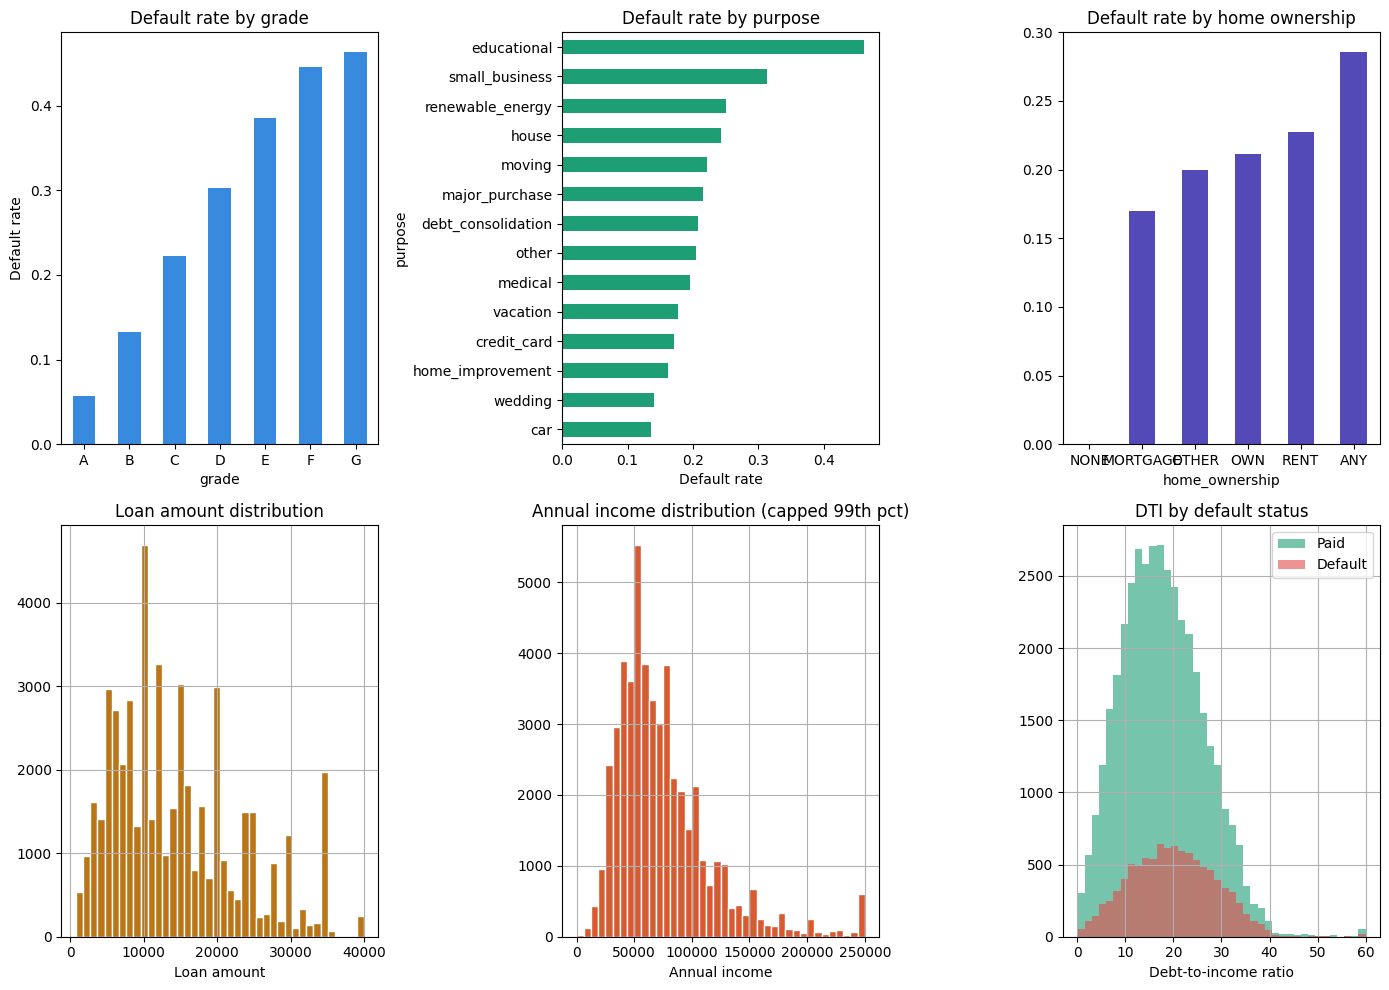

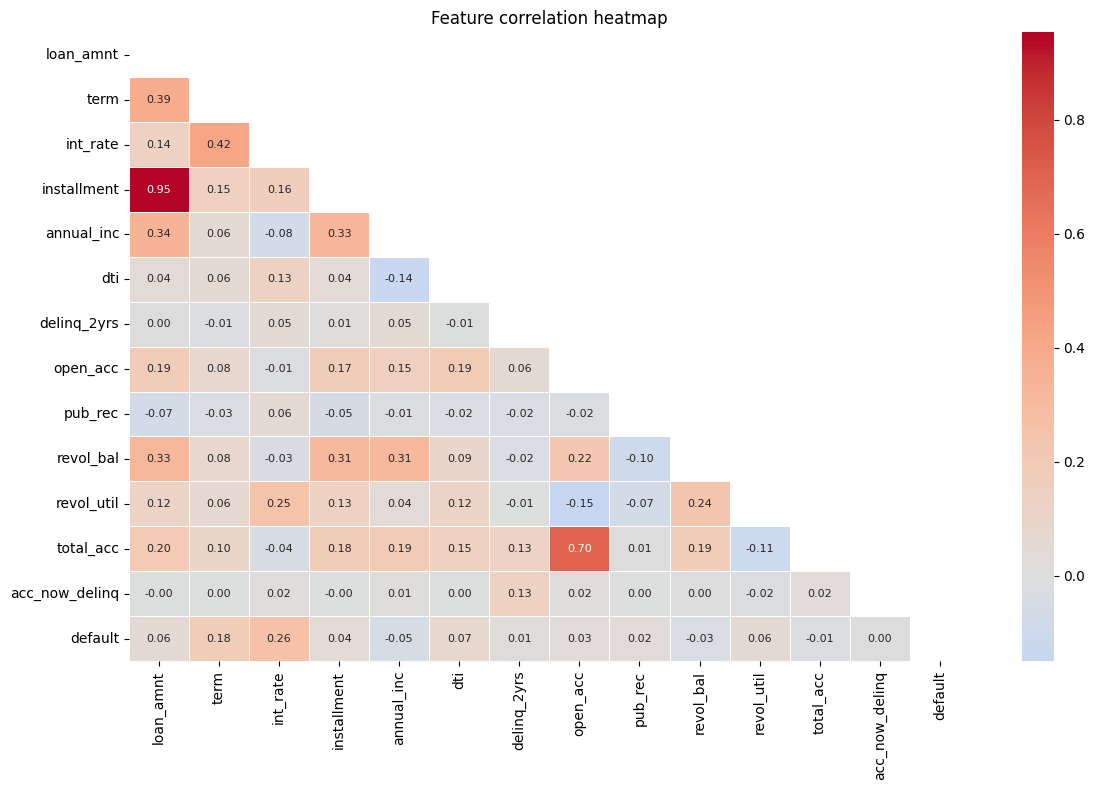


Outlier check (99th percentile):
  loan_amnt: 344 rows above 99th pct (35,000)
  annual_inc: 469 rows above 99th pct (250,000)
  revol_bal: 500 rows above 99th pct (94,801)
  dti: 500 rows above 99th pct (38)


In [11]:
import os

# Create the directory if it doesn't exist
os.makedirs('ml_credit', exist_ok=True)

# ── 3. Default rate by grade ───────────────────────────────────────
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
df.groupby('grade')['default'].mean().sort_index().plot(kind='bar', color='#378ADD')
plt.title('Default rate by grade')
plt.ylabel('Default rate')
plt.xticks(rotation=0)

# ── 4. Default rate by purpose ─────────────────────────────────────
plt.subplot(2, 3, 2)
df.groupby('purpose')['default'].mean().sort_values().plot(kind='barh', color='#1D9E75')
plt.title('Default rate by purpose')
plt.xlabel('Default rate')

# ── 5. Default rate by home ownership ─────────────────────────────
plt.subplot(2, 3, 3)
df.groupby('home_ownership')['default'].mean().sort_values().plot(kind='bar', color='#534AB7')
plt.title('Default rate by home ownership')
plt.xticks(rotation=0)

# ── 6. Distribution of loan amount ────────────────────────────────
plt.subplot(2, 3, 4)
df['loan_amnt'].hist(bins=40, color='#BA7517', edgecolor='white')
plt.title('Loan amount distribution')
plt.xlabel('Loan amount')

# ── 7. Distribution of annual income (capped at 99th percentile) ──
plt.subplot(2, 3, 5)
cap = df['annual_inc'].quantile(0.99)
df['annual_inc'].clip(upper=cap).hist(bins=40, color='#D85A30', edgecolor='white')
plt.title('Annual income distribution (capped 99th pct)')
plt.xlabel('Annual income')

# ── 8. DTI distribution by default ────────────────────────────────
plt.subplot(2, 3, 6)
df[df['default']==0]['dti'].clip(upper=60).hist(bins=40, alpha=0.6, label='Paid', color='#1D9E75')
df[df['default']==1]['dti'].clip(upper=60).hist(bins=40, alpha=0.6, label='Default', color='#E24B4A')
plt.title('DTI by default status')
plt.xlabel('Debt-to-income ratio')
plt.legend()

plt.tight_layout()
plt.savefig('ml_credit/eda_overview.png', dpi=150)
plt.show()

# ── 9. Correlation heatmap ─────────────────────────────────────────
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('ml_credit/correlation_heatmap.png', dpi=150)
plt.show()

# ── 10. Outlier check ──────────────────────────────────────────────
print("\nOutlier check (99th percentile):")
for col in ['loan_amnt', 'annual_inc', 'revol_bal', 'dti']:
    p99 = df[col].quantile(0.99)
    extreme = (df[col] > p99).sum()
    print(f"  {col}: {extreme} rows above 99th pct ({p99:,.0f})")

In [12]:
# 1. Drop highly correlated redundant features
# installment ≈ loan_amnt (0.95) → drop installment
# total_acc ≈ open_acc (0.70) → drop total_acc
df = df.drop(columns=['installment', 'total_acc'])
print("After dropping correlated features:", df.shape)

After dropping correlated features: (50000, 17)


In [13]:
# 2. Ordinal encode grade (A=1 best, G=7 worst)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)
print("Grade encoded:", df['grade'].value_counts().sort_index())

Grade encoded: grade
1     8873
2    14518
3    14162
4     7445
5     3457
6     1202
7      343
Name: count, dtype: int64


In [14]:
# ── 3. Cap outliers at 99th percentile ────────────────────────────
for col in ['loan_amnt', 'annual_inc', 'revol_bal', 'dti']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# 4. Log transform skewed features
df['log_annual_inc'] = np.log1p(df['annual_inc'])
df['log_revol_bal']  = np.log1p(df['revol_bal'])
df = df.drop(columns=['annual_inc', 'revol_bal'])
print("Log transforms applied")


Log transforms applied


In [15]:
# 5. Engineer new features

# How much of monthly income goes to repayment
df['payment_to_income'] = df['loan_amnt'] / (df['log_annual_inc'] + 1)

# Combined delinquency risk score
df['delinquency_score'] = (
    df['delinq_2yrs'] * 2 +
    df['acc_now_delinq'] * 3 +
    df['pub_rec'] * 1
)

# Credit utilisation risk
df['credit_util_risk'] = df['revol_util'] / (df['loan_amnt'] + 1)

# Income to loan ratio — can they realistically repay?
df['income_loan_ratio'] = df['log_annual_inc'] / (df['loan_amnt'] + 1)

# High risk purpose flag (from EDA — educational + small_business default 45%+)
high_risk_purposes = ['educational', 'small_business', 'renewable_energy']
df['high_risk_purpose'] = df['purpose'].isin(high_risk_purposes).astype(int)

# Interest rate x term interaction — long term + high rate = danger
df['rate_term_risk'] = df['int_rate'] * df['term']

# DTI risk bucket
df['dti_risk'] = pd.cut(df['dti'],
    bins=[-1, 10, 20, 30, 100],
    labels=[0, 1, 2, 3]
).astype(int)

print("New features engineered")
print(f"\nShape after feature engineering: {df.shape}")

New features engineered

Shape after feature engineering: (50000, 24)


In [16]:
# 6. Encode remaining categoricals
from sklearn.preprocessing import LabelEncoder
cat_cols = ['term', 'emp_length', 'home_ownership',
            'verification_status', 'purpose']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [17]:
#  7. Mutual information — rank features by predictive power
X = df.drop(columns=['default'])
y = df['default']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nFeature importance (mutual information):")
print(mi_df.to_string(index=False))



Feature importance (mutual information):
            feature  mi_score
     rate_term_risk  0.040892
           int_rate  0.035457
              grade  0.034974
               term  0.017306
     home_ownership  0.009445
verification_status  0.008031
            purpose  0.005616
     log_annual_inc  0.005548
           dti_risk  0.005379
  payment_to_income  0.004902
  income_loan_ratio  0.004567
                dti  0.003916
      log_revol_bal  0.003824
          loan_amnt  0.003697
         revol_util  0.002441
         emp_length  0.002315
   credit_util_risk  0.001868
        delinq_2yrs  0.001236
           open_acc  0.001076
            pub_rec  0.000709
  high_risk_purpose  0.000488
  delinquency_score  0.000190
     acc_now_delinq  0.000014


In [18]:
# Final feature selection
top_features = [
    'rate_term_risk', 'int_rate','term',
    'home_ownership', 'verification_status', 'purpose',
    'log_annual_inc', 'dti_risk', 'payment_to_income',
    'income_loan_ratio', 'dti', 'log_revol_bal',
    'loan_amnt', 'revol_util', 'emp_length'
]

In [19]:
X = df[top_features]
y = df['default']

In [20]:
print(f"Final feature set: {X.shape}")
print(f"nFeatures kept: {top_features}")

Final feature set: (50000, 15)
nFeatures kept: ['rate_term_risk', 'int_rate', 'term', 'home_ownership', 'verification_status', 'purpose', 'log_annual_inc', 'dti_risk', 'payment_to_income', 'income_loan_ratio', 'dti', 'log_revol_bal', 'loan_amnt', 'revol_util', 'emp_length']


In [21]:
#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")



Train: (40000, 15) | Test: (10000, 15)


In [22]:
# save final dataset
import os
os.makedirs('ml_credit/data', exist_ok=True)
model_ready = X.copy()
model_ready['default'] = y.values
model_ready.to_csv('ml_credit/data/lending_club_model_ready.csv', index=False)
print("\nSaved to ml_credit/data/lending_club_model_ready.csv")


Saved to ml_credit/data/lending_club_model_ready.csv


In [23]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)


In [24]:
# ── Scale pos weight to handle 80/20 imbalance
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale:.2f}")

scale_pos_weight: 4.07


In [25]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30,
    verbosity=1,
)

In [26]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)


[0]	validation_0-auc:0.70778	validation_1-auc:0.69195
[50]	validation_0-auc:0.74677	validation_1-auc:0.70545
[100]	validation_0-auc:0.77018	validation_1-auc:0.70474
[115]	validation_0-auc:0.77605	validation_1-auc:0.70443


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]



  AUC-ROC Score: 0.7057

Classification Report:
              precision    recall  f1-score   support

        Paid       0.88      0.64      0.74      8028
     Default       0.31      0.65      0.42      1972

    accuracy                           0.64     10000
   macro avg       0.59      0.64      0.58     10000
weighted avg       0.77      0.64      0.68     10000



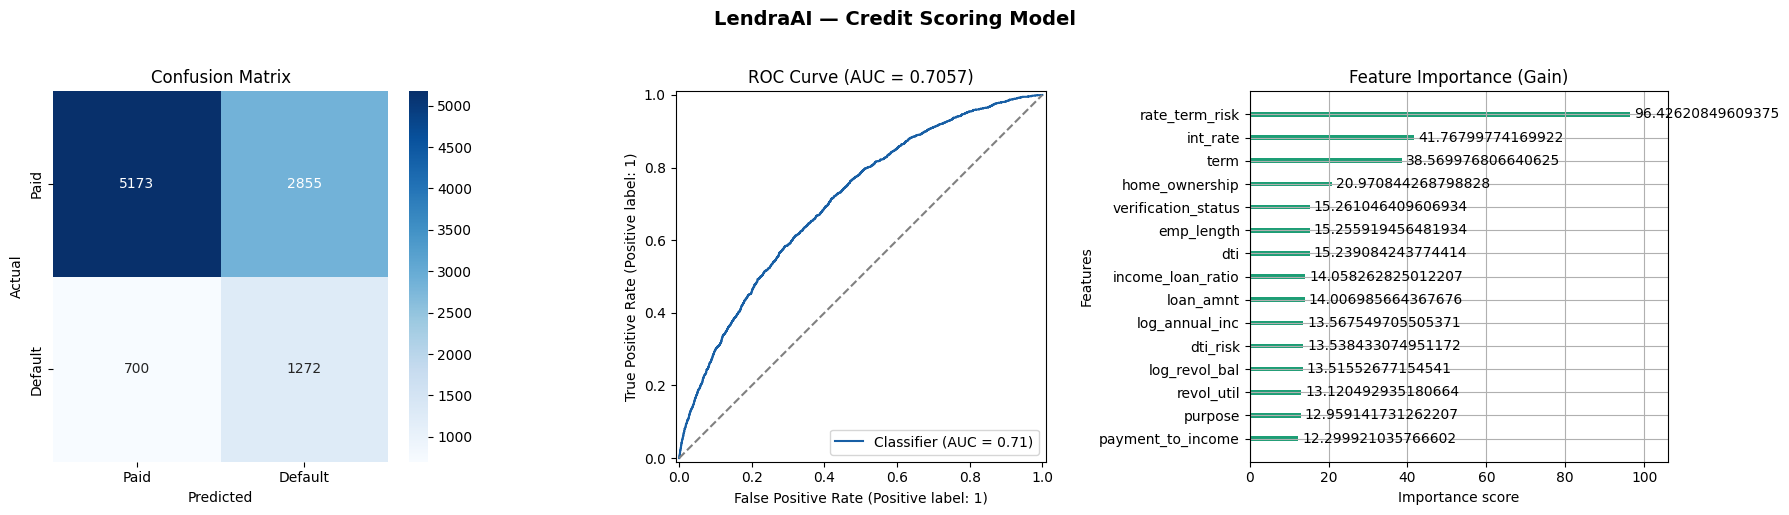

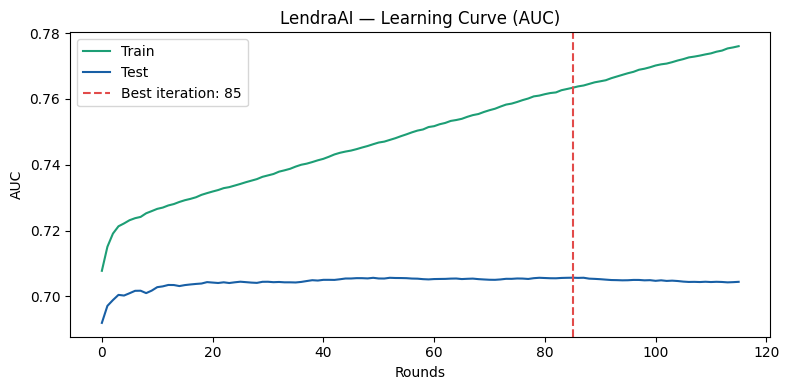


Best iteration: 85
Best test AUC:  0.7057

Model saved to ml_credit/models/lendraai_credit_model.pkl


In [28]:
auc = roc_auc_score(y_test, y_prob)
print(f"\n{'='*40}")
print(f"  AUC-ROC Score: {auc:.4f}")
print(f"{'='*40}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Paid', 'Default'])}")

#  Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Paid', 'Default'],
            yticklabels=['Paid', 'Default'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='#185FA5')
axes[1].set_title(f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0,1],[0,1],'--', color='gray')

# Feature importance
xgb.plot_importance(model, ax=axes[2], max_num_features=15,
                    importance_type='gain', color='#1D9E75')
axes[2].set_title('Feature Importance (Gain)')

plt.suptitle('LendraAI — Credit Scoring Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_credit/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Learning curve (train vs test AUC over rounds) ────────────────
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(8, 4))
plt.plot(x_axis, results['validation_0']['auc'], label='Train', color='#1D9E75')
plt.plot(x_axis, results['validation_1']['auc'], label='Test', color='#185FA5')
plt.axvline(model.best_iteration, color='#E24B4A', linestyle='--', label=f'Best iteration: {model.best_iteration}')
plt.title('LendraAI — Learning Curve (AUC)')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig('ml_credit/learning_curve.png', dpi=150)
plt.show()

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best test AUC:  {model.best_score:.4f}")

# Save model
import os, joblib
os.makedirs('ml_credit/models', exist_ok=True)
joblib.dump(model, 'ml_credit/models/lendraai_credit_model.pkl')
print("\nModel saved to ml_credit/models/lendraai_credit_model.pkl")

In [29]:
from google.colab import files


In [30]:
files.download("ml_credit/models/lendraai_credit_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[0]	validation_0-auc:0.69375	validation_1-auc:0.68984
[100]	validation_0-auc:0.71065	validation_1-auc:0.70337
[200]	validation_0-auc:0.71508	validation_1-auc:0.70512
[300]	validation_0-auc:0.71938	validation_1-auc:0.70602
[400]	validation_0-auc:0.72288	validation_1-auc:0.70667
[500]	validation_0-auc:0.72617	validation_1-auc:0.70690
[508]	validation_0-auc:0.72642	validation_1-auc:0.70688

  v1 AUC: 0.7057
  v2 AUC: 0.7069

              precision    recall  f1-score   support

        Paid       0.88      0.62      0.73      8028
     Default       0.30      0.66      0.41      1972

    accuracy                           0.63     10000
   macro avg       0.59      0.64      0.57     10000
weighted avg       0.77      0.63      0.67     10000



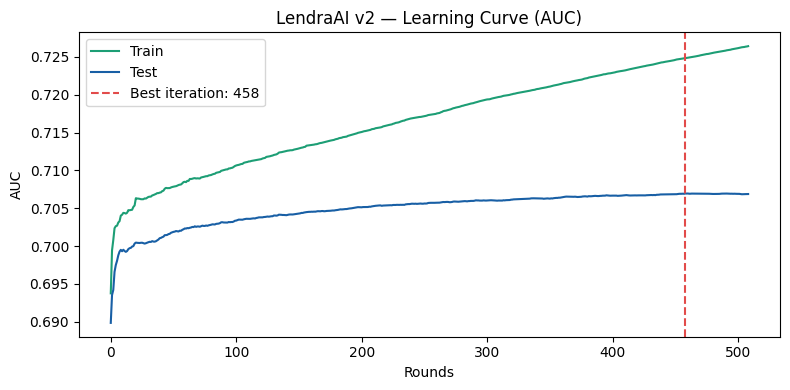


Best iteration: 458
Best test AUC:  0.7069

v2 is better — model updated and saved!


In [31]:
# Round 2 — fix overfitting + push AUC higher

# stronger regularisation to close the train/test gap
model_v2 = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,           # reduced from 6 — shallower trees overfit less
    learning_rate=0.01,    # slower learning = better generalisation
    subsample=0.7,         # reduced from 0.8
    colsample_bytree=0.6,  # reduced from 0.8
    min_child_weight=10,   # increased from 5 — more conservative splits
    gamma=0.3,             # increased from 0.1
    reg_alpha=0.5,         # increased from 0.1
    reg_lambda=2.0,        # increased from 1.0
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=1,
)

model_v2.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100,
)

y_pred_v2 = model_v2.predict(X_test)
y_prob_v2 = model_v2.predict_proba(X_test)[:, 1]

auc_v2 = roc_auc_score(y_test, y_prob_v2)
print(f"\n{'='*40}")
print(f"  v1 AUC: 0.7057")
print(f"  v2 AUC: {auc_v2:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_test, y_pred_v2, target_names=['Paid', 'Default'])}")

# learning curve
results_v2 = model_v2.evals_result()
epochs = len(results_v2['validation_0']['auc'])

plt.figure(figsize=(8, 4))
plt.plot(results_v2['validation_0']['auc'], label='Train', color='#1D9E75')
plt.plot(results_v2['validation_1']['auc'], label='Test', color='#185FA5')
plt.axvline(model_v2.best_iteration, color='#E24B4A', linestyle='--',
            label=f'Best iteration: {model_v2.best_iteration}')
plt.title('LendraAI v2 — Learning Curve (AUC)')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig('ml_credit/learning_curve_v2.png', dpi=150)
plt.show()

print(f"\nBest iteration: {model_v2.best_iteration}")
print(f"Best test AUC:  {model_v2.best_score:.4f}")

# save if better
if auc_v2 > 0.7057:
    joblib.dump(model_v2, 'ml_credit/models/lendraai_credit_model.pkl')
    print("\nv2 is better — model updated and saved!")
else:
    print("\nv2 did not improve — keeping v1")

In [32]:
files.download("ml_credit/models/lendraai_credit_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
files.download("ml_credit/data/lending_club_model_ready.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>